In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import f1_score, ConfusionMatrixDisplay
import pandas as pd
import os
from tensorflow.keras.callbacks import ModelCheckpoint
import pickle

In [2]:
all_data = []
all_labels = []

def file_open(file_path):
    try:
        with open(file_path, 'rb') as f:
            data_dict = pickle.load(f, encoding='latin1')
            all_data.append(data_dict['data'])  
            all_labels.extend(data_dict['labels'])  
    except FileNotFoundError:
        print(f"File not found: {file_path}")
    except Exception as e:
        print(f"Error loading file {file_path}: {e}")

# Load all batches
base_path = r'.\Dataset\cifar-10-batches-py'
for i in range(1, 6):
    file_path = os.path.join(base_path, f"data_batch_{i}")
    file_open(file_path)


all_data = np.vstack(all_data)  # Stack all data arrays vertically
all_labels = np.array(all_labels)  

print(f"Data shape: {all_data.shape}")  
print(f"Labels shape: {all_labels.shape}")  

Data shape: (50000, 3072)
Labels shape: (50000,)


In [3]:
data = pd.DataFrame({
    'image_data': list(all_data),  
    'fine_label': all_labels  
})

In [4]:
data['image_data'] = data['image_data'].apply(
    lambda x: np.array(x).reshape((3, 32, 32)).transpose(1, 2, 0)
)

In [5]:
data.shape

(50000, 2)

In [6]:
data['image_data']

0        [[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...
1        [[[154, 177, 187], [126, 137, 136], [105, 104,...
2        [[[255, 255, 255], [253, 253, 253], [253, 253,...
3        [[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...
4        [[[170, 180, 198], [168, 178, 196], [177, 185,...
                               ...                        
49995    [[[145, 161, 194], [151, 166, 199], [156, 171,...
49996    [[[255, 245, 132], [254, 247, 134], [255, 249,...
49997    [[[35, 178, 235], [40, 176, 239], [42, 176, 24...
49998    [[[189, 211, 240], [186, 208, 236], [185, 207,...
49999    [[[229, 229, 239], [236, 237, 247], [234, 236,...
Name: image_data, Length: 50000, dtype: object

In [7]:
data['fine_label'].value_counts()

fine_label
6    5000
9    5000
4    5000
1    5000
2    5000
7    5000
8    5000
3    5000
5    5000
0    5000
Name: count, dtype: int64

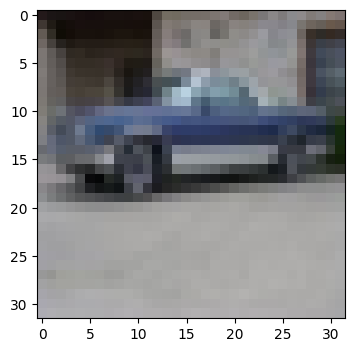

In [8]:
img = data['image_data'][10000]
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.show()

In [9]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

In [10]:
gpus

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, BatchNormalization, Dropout, RandomFlip, RandomRotation
from keras.preprocessing.image import ImageDataGenerator

In [12]:
from tensorflow.keras.preprocessing.image import random_rotation

In [13]:
df = pd.DataFrame(data)

# Data augmentation
def augment_image(image_array):
    image = tf.convert_to_tensor(image_array, dtype=tf.float32)
    image = tf.image.random_flip_left_right(image)  
    image = tf.image.random_flip_up_down(image)    
    image = tf.image.random_brightness(image, max_delta=0.2) 
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)  
    image = tf.image.random_saturation(image, lower=0.8, upper=1.2)
    image = tf.image.random_hue(image, max_delta=0.02)  
    return image.numpy()

# Function to create multiple augmented images for each row
def create_augmented_images(image_array, fine_label, num_augments=2):
    augmented_images = []
    for _ in range(num_augments):
        augmented_images.append({"image_data": augment_image(image_array), "fine_label": fine_label})
    return augmented_images

# Generate augmented data for the entire DataFrame
augmented_data = []
for _, row in df.iterrows():
    augmented_data.extend(create_augmented_images(row["image_data"], row["fine_label"], num_augments=2))


augmented_df = pd.DataFrame(augmented_data)
print(augmented_df.head())

                                          image_data  fine_label
0  [[[121.36267, 93.48108, 66.53429], [151.9018, ...           6
1  [[[147.90085, 125.50023, 110.00429], [151.8170...           6
2  [[[142.33578, 133.99936, 142.35976], [141.4550...           9
3  [[[79.27944, 80.61887, 71.392746], [87.726685,...           9
4  [[[70.16242, 76.91392, 75.79404], [68.97924, 7...           9


In [15]:
df.shape

(50000, 2)

In [16]:
df.head()

,image_data,fine_label
0,"[[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...",6
1,"[[[154, 177, 187], [126, 137, 136], [105, 104,...",9
2,"[[[255, 255, 255], [253, 253, 253], [253, 253,...",9
3,"[[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...",4
4,"[[[170, 180, 198], [168, 178, 196], [177, 185,...",1


In [17]:
merged_df = pd.concat([df, augmented_df], ignore_index=True)

In [18]:
merged_df.to_csv("merged_df.csv", index=False)

In [19]:
merged_df.head()

,image_data,fine_label
0,"[[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...",6
1,"[[[154, 177, 187], [126, 137, 136], [105, 104,...",9
2,"[[[255, 255, 255], [253, 253, 253], [253, 253,...",9
3,"[[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...",4
4,"[[[170, 180, 198], [168, 178, 196], [177, 185,...",1


In [20]:
merged_df.shape

(150000, 2)

In [21]:
model = Sequential()

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D

# Instantiate the Sequential model
model = Sequential()

# Block 1
model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Block 2
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

# Block 3
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))


model.add(GlobalAveragePooling2D())
model.add(Dense(2000, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))  # 100 classes for CIFAR-100

In [25]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 64)        1792      
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 64)        36928     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 64)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 256)       147712    
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 256)       590080    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 8, 256)        0         
 2D)                                                  

In [26]:
model.compile(loss=tf.keras.losses.sparse_categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=[tf.keras.metrics.sparse_categorical_accuracy])

In [27]:
merged_df.head()

,image_data,fine_label
0,"[[[59, 62, 63], [43, 46, 45], [50, 48, 43], [6...",6
1,"[[[154, 177, 187], [126, 137, 136], [105, 104,...",9
2,"[[[255, 255, 255], [253, 253, 253], [253, 253,...",9
3,"[[[28, 25, 10], [37, 34, 19], [38, 35, 20], [4...",4
4,"[[[170, 180, 198], [168, 178, 196], [177, 185,...",1


In [28]:
merged_df['image_data'] = merged_df['image_data'] / 255.0

In [29]:
merged_df['image_data'] = merged_df['image_data'].map(lambda x: (np.round(x, 2)))

In [30]:
merged_df.head()

,image_data,fine_label
0,"[[[0.23, 0.24, 0.25], [0.17, 0.18, 0.18], [0.2...",6
1,"[[[0.6, 0.69, 0.73], [0.49, 0.54, 0.53], [0.41...",9
2,"[[[1.0, 1.0, 1.0], [0.99, 0.99, 0.99], [0.99, ...",9
3,"[[[0.11, 0.1, 0.04], [0.15, 0.13, 0.07], [0.15...",4
4,"[[[0.67, 0.71, 0.78], [0.66, 0.7, 0.77], [0.69...",1


In [31]:
merged_df["fine_label"].value_counts()

fine_label
6    15000
9    15000
4    15000
1    15000
2    15000
7    15000
8    15000
3    15000
5    15000
0    15000
Name: count, dtype: int64

In [32]:
train = merged_df.groupby('fine_label').apply(lambda x: x.sample(15000)).reset_index(drop=True)

In [33]:
images = np.array(train['image_data'].tolist())  # Convert list of 3D arrays to numpy array
labels = np.array(train['fine_label'])  

In [34]:
images.shape

(150000, 32, 32, 3)

In [35]:
labels.shape

(150000,)

In [36]:
valid = merged_df.groupby('fine_label').apply(lambda x: x.sample(500)).reset_index(drop=True)

In [37]:
valid = valid.sample(frac=1)

In [38]:
images_valid = np.array(valid['image_data'].tolist())
labels_valid = np.array(valid['fine_label'])

In [39]:
model_checkpoint = ModelCheckpoint('VGG.h5', save_best_only=True, monitor="val_loss")

In [40]:
images.shape

(150000, 32, 32, 3)

In [41]:
training = model.fit(images, labels,batch_size=32, epochs=25, validation_data=(images_valid, labels_valid), callbacks=[model_checkpoint])

Epoch 1/25
4688/4688 [==============================] - 44s 8ms/step - loss: 2.1225 - sparse_categorical_accuracy: 0.1925 - val_loss: 2.0533 - val_sparse_categorical_accuracy: 0.2276
Epoch 2/25
4688/4688 [==============================] - 34s 7ms/step - loss: 1.8003 - sparse_categorical_accuracy: 0.3178 - val_loss: 1.6489 - val_sparse_categorical_accuracy: 0.3776
Epoch 3/25
4688/4688 [==============================] - 34s 7ms/step - loss: 1.5599 - sparse_categorical_accuracy: 0.4204 - val_loss: 1.4907 - val_sparse_categorical_accuracy: 0.4400
Epoch 4/25
4688/4688 [==============================] - 34s 7ms/step - loss: 1.3784 - sparse_categorical_accuracy: 0.4937 - val_loss: 1.2676 - val_sparse_categorical_accuracy: 0.5342
Epoch 5/25
4688/4688 [==============================] - 35s 7ms/step - loss: 1.2308 - sparse_categorical_accuracy: 0.5533 - val_loss: 1.1871 - val_sparse_categorical_accuracy: 0.5648
Epoch 6/25
4688/4688 [==============================] - 39s 8ms/step - loss: 1.0952 -

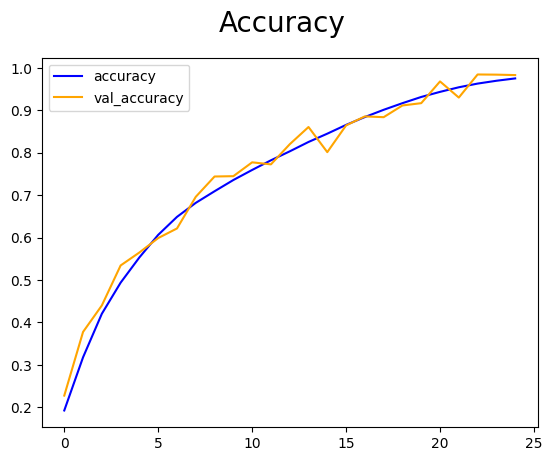

In [46]:
fig = plt.figure()
plt.plot(training.history['sparse_categorical_accuracy'], color='blue', label='accuracy')
plt.plot(training.history['val_sparse_categorical_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

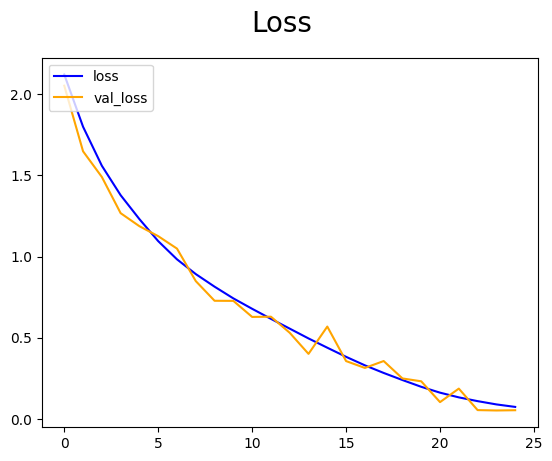

In [44]:
fig = plt.figure()
plt.plot(training.history['loss'], color='blue', label='loss')
plt.plot(training.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [42]:
file_path = r'.\Dataset\cifar-10-batches-py\test_batch'

with open(file_path, 'rb') as f:
    test_dict = pickle.load(f, encoding='latin1')

print(test_dict.keys())  

dict_keys(['batch_label', 'labels', 'data', 'filenames'])


In [47]:
test = pd.DataFrame({
    'image_data': list(test_dict['data']),  
    'label': test_dict['labels']  
})

In [48]:
test.head()

,image_data,label
0,"[158, 159, 165, 166, 160, 156, 162, 159, 158, ...",3
1,"[235, 231, 232, 232, 232, 232, 232, 232, 232, ...",8
2,"[158, 158, 139, 132, 166, 182, 187, 193, 199, ...",8
3,"[155, 167, 176, 190, 177, 166, 168, 166, 170, ...",0
4,"[65, 70, 48, 30, 23, 40, 44, 45, 45, 40, 10, 1...",6


In [49]:
test['image_data'] = test['image_data'].apply(
    lambda x: np.array(x).reshape((3, 32, 32)).transpose(1, 2, 0)
)

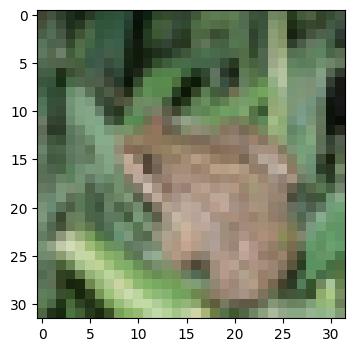

In [50]:
plt.figure(figsize=(4, 4))
plt.imshow(test['image_data'][4])
plt.show()

In [51]:
test.head()

,image_data,label
0,"[[[158, 112, 49], [159, 111, 47], [165, 116, 5...",3
1,"[[[235, 235, 235], [231, 231, 231], [232, 232,...",8
2,"[[[158, 190, 222], [158, 187, 218], [139, 166,...",8
3,"[[[155, 156, 149], [167, 176, 187], [176, 179,...",0
4,"[[[65, 68, 50], [70, 81, 64], [48, 64, 46], [3...",6


In [52]:
test['image_data'] = test['image_data'] / 255.0

In [53]:
test['image_data'] = test['image_data'].map(lambda x: (np.round(x, 2)))

In [54]:
test.head()

,image_data,label
0,"[[[0.62, 0.44, 0.19], [0.62, 0.44, 0.18], [0.6...",3
1,"[[[0.92, 0.92, 0.92], [0.91, 0.91, 0.91], [0.9...",8
2,"[[[0.62, 0.75, 0.87], [0.62, 0.73, 0.85], [0.5...",8
3,"[[[0.61, 0.61, 0.58], [0.65, 0.69, 0.73], [0.6...",0
4,"[[[0.25, 0.27, 0.2], [0.27, 0.32, 0.25], [0.19...",6


In [55]:
test_images = np.array(test['image_data'].tolist())  
test_labels = np.array(test['label'])  

In [56]:
model.evaluate(test_images, test_labels)

313/313 [==============================] - 1s 4ms/step - loss: 0.9349 - sparse_categorical_accuracy: 0.7953


[0.9349265694618225, 0.7953000068664551]

In [57]:
test_pred = model.predict(test_images)

In [58]:
test_pred[0]

array([8.7597741e-08, 1.3885880e-06, 2.1896644e-09, 9.9991465e-01,
       1.0789687e-09, 4.1438266e-06, 9.7771938e-08, 7.9473888e-05,
       1.2445981e-09, 1.8179205e-07], dtype=float32)

In [59]:
test_pred = test_pred.argmax(axis=-1)

In [60]:
f1_class = f1_score(test_labels, test_pred,average=None)
print(f1_class)

[0.82881105 0.88202247 0.74113856 0.63037475 0.77633008 0.70694224
 0.8287708  0.85087282 0.87672689 0.86690464]


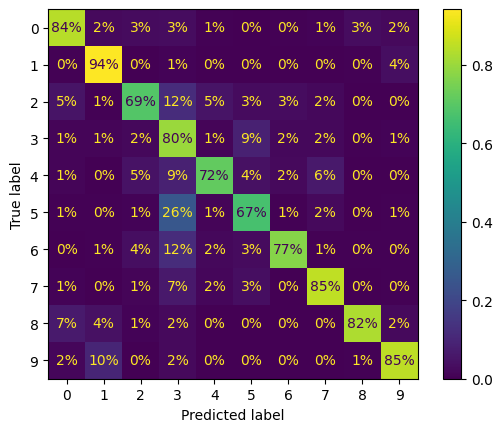

In [61]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_pred, normalize='true', values_format='.0%')

In [62]:
model.save(os.path.join('models','cifer_classifier_VGG.h5'))